# 1. DEFINIÇÃO DE PROBLEMA DE NEGÓCIO

Um banco português realizou campanhas de marketing direto (via chamadas por telefone) para vender depósitos a prazo, porém ligar para qualquer pessoa em busca de vendas pode ser considerado um tiro no escuro, fazendo o banco perder tempo e dinheiro.

Logo, o nosso objetivo é descobrir o perfil dos clientes que costumam comprar o produto, para o banco criar campanhas de marketing mais direcionadas e com maior probabilidade de converter as ligações em vendas, diminuindo o custo e aumentando a receita.

Para isso, iremos analisar as campanhas passadas de marketing e criar um modelo de classificação para prever se um possível novo cliente tende a comprar o produto ou não.

# 2. COLETA E ENTENDIMENTO DOS DADOS  

## 2.1 IMPORTANDO BIBLIOTECAS

In [2]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Define o estilo dos gráficos
plt.style.use("ggplot")

#Exibe todas as colunas de um Dataframe
pd.set_option('display.max_columns', None)

#Selecionando cor padrão
cor_base = '#5B2C6F'
cor_secundaria = '#D35400'

## 2.2 COLETA DOS DADOS

Nosso dataset foi coletado da base de dados da University of California, Irvine. Ele nos traz informações sobre campanhas de telemarketing realizadas por um banco português para vender depósitos a prazo (um tipo de investimento) e se elas foram bem sucedidas ou não.

In [3]:
bank = pd.read_csv(r"C:\Users\felip\OneDrive\Documentos\Bases de Dados\Bank Marketing\bank\bank-full.csv", sep=';')
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### O que significa cada coluna:

Informações sobre o possível cliente:
- age (idade): A idade do cliente.

- job (trabalho): Tipo de emprego.

- marital (estado Civil): Estado civil.

- education (educação): Nível de escolaridade.

- default (inadimplência): O cliente tem crédito em inadimplência/calote?

- balance (saldo): Saldo médio anual em euros.

- housing (habitação): Tem empréstimo imobiliário/financiamento da casa?

- loan (empréstimo): Tem empréstimo pessoal?


Informações sobre o contato da campanha atual:

- contact (contato): Tipo de comunicação do contato.

- month (mês): Mês do último contato.

- day (dia): Dia do mês do último contato.

- duration (duração): Duração do último contato em segundos.

- campaign (campanha): Número de contatos realizados durante esta campanha para este cliente.


Informações sobre o contato de campanhas anteriores:

- pdays (dias passados): Número de dias que se passaram desde que o cliente foi contatado pela última vez em uma campanha anterior (-1 significa que o cliente não foi contatado anteriormente).

- previous (anteriores): Número de contatos realizados antes desta campanha para este cliente.

- poutcome (resultado anterior): Resultado da campanha de marketing anterior.

Target:

- y: O cliente subscreveu/assinou um depósito a prazo?

## 2.3 INFORMAÇÕES SOBRE O DATASET

### Informações gerais

In [4]:
print(f"O nosso dataset tem {bank.shape[1]} colunas e {bank.shape[0]} linhas.")
print("-" * 30)
print("Informações principais:\n")
print(bank.info())

O nosso dataset tem 17 colunas e 45211 linhas.
------------------------------
Informações principais:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+

In [5]:
bank.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Missing values

Algo a se notar nesse dataset é que por mais que ele não tenha valores nulos (nan), os missing values estão representados como "unknown", logo eu irei transformá-los em nan para uma análise mais realista

In [6]:
bank.replace("unknown", np.nan, inplace=True)
bank.isnull().sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

In [7]:
condicao = bank['pdays'] == -1
print(f'Número de pessoas que não foram contatadas anteriormente: {bank[condicao].shape[0]}')

Número de pessoas que não foram contatadas anteriormente: 36954


A variável poutcome tem 36.959 valores ausentes. Olhando inicialmente, pode parecer um valor muito grande, porém o número de pessoas que não foram contatadas anteriormente (pdays = -1) bate quase exatamente o mesmo valor, então os valores ausentes dessa colunas são de pessoas que não foram contatadas anteriormente. Contendo apenas 5 valores que realmente são erros de coleta de dados.

# 3. EDA

Eu irei separar a análise em 4 etapas:
- Análise Univariada: A distribuição de cada uma das nossas variáveis.
- Perifl do cliente: Os clientes que são investem no nosso produto têm algum padrão?
- Comportamento do cliente: Eles já terem recebido uma ligação antes os afeta? A sazonalidade é um fator que devemos nos atentar?
- Operação: Como otimizar as nossas ligações para obter maior taxa de conversão em clientes.

Para facilitar a leitura dos gráficos, eu irei traduzir o nosso dataset para língua portuguesa.

In [8]:
dic_job = {
    'admin.': 'Administrativo',
    'blue-collar': 'Operário/Manual',
    'entrepreneur': 'Empreendedor',
    'housemaid': 'Doméstica',
    'management': 'Gerência',
    'retired': 'Aposentado',
    'self-employed': 'Autônomo',
    'services': 'Serviços',
    'student': 'Estudante',
    'technician': 'Técnico',
    'unemployed': 'Desempregado',
}

dic_marital = {
    'married': 'Casado(a)',
    'single': 'Solteiro(a)',
    'divorced': 'Divorciado(a)'
}

dic_education = {
    'primary': 'Fundamental',
    'secondary': 'Ensino Médio',
    'tertiary': 'Superior',
}

dic_binary = {'yes': 'Sim', 'no': 'Não'}

# Aplicando as traduções

bank['job'] = bank['job'].map(dic_job)
bank['marital'] = bank['marital'].map(dic_marital)
bank['education'] = bank['education'].map(dic_education)
bank['default'] = bank['default'].map(dic_binary)
bank['housing'] = bank['housing'].map(dic_binary)
bank['loan'] = bank['loan'].map(dic_binary)
bank['y'] = bank['y'].map(dic_binary)

## 3.1 ANÁLISE UNIVARIADA

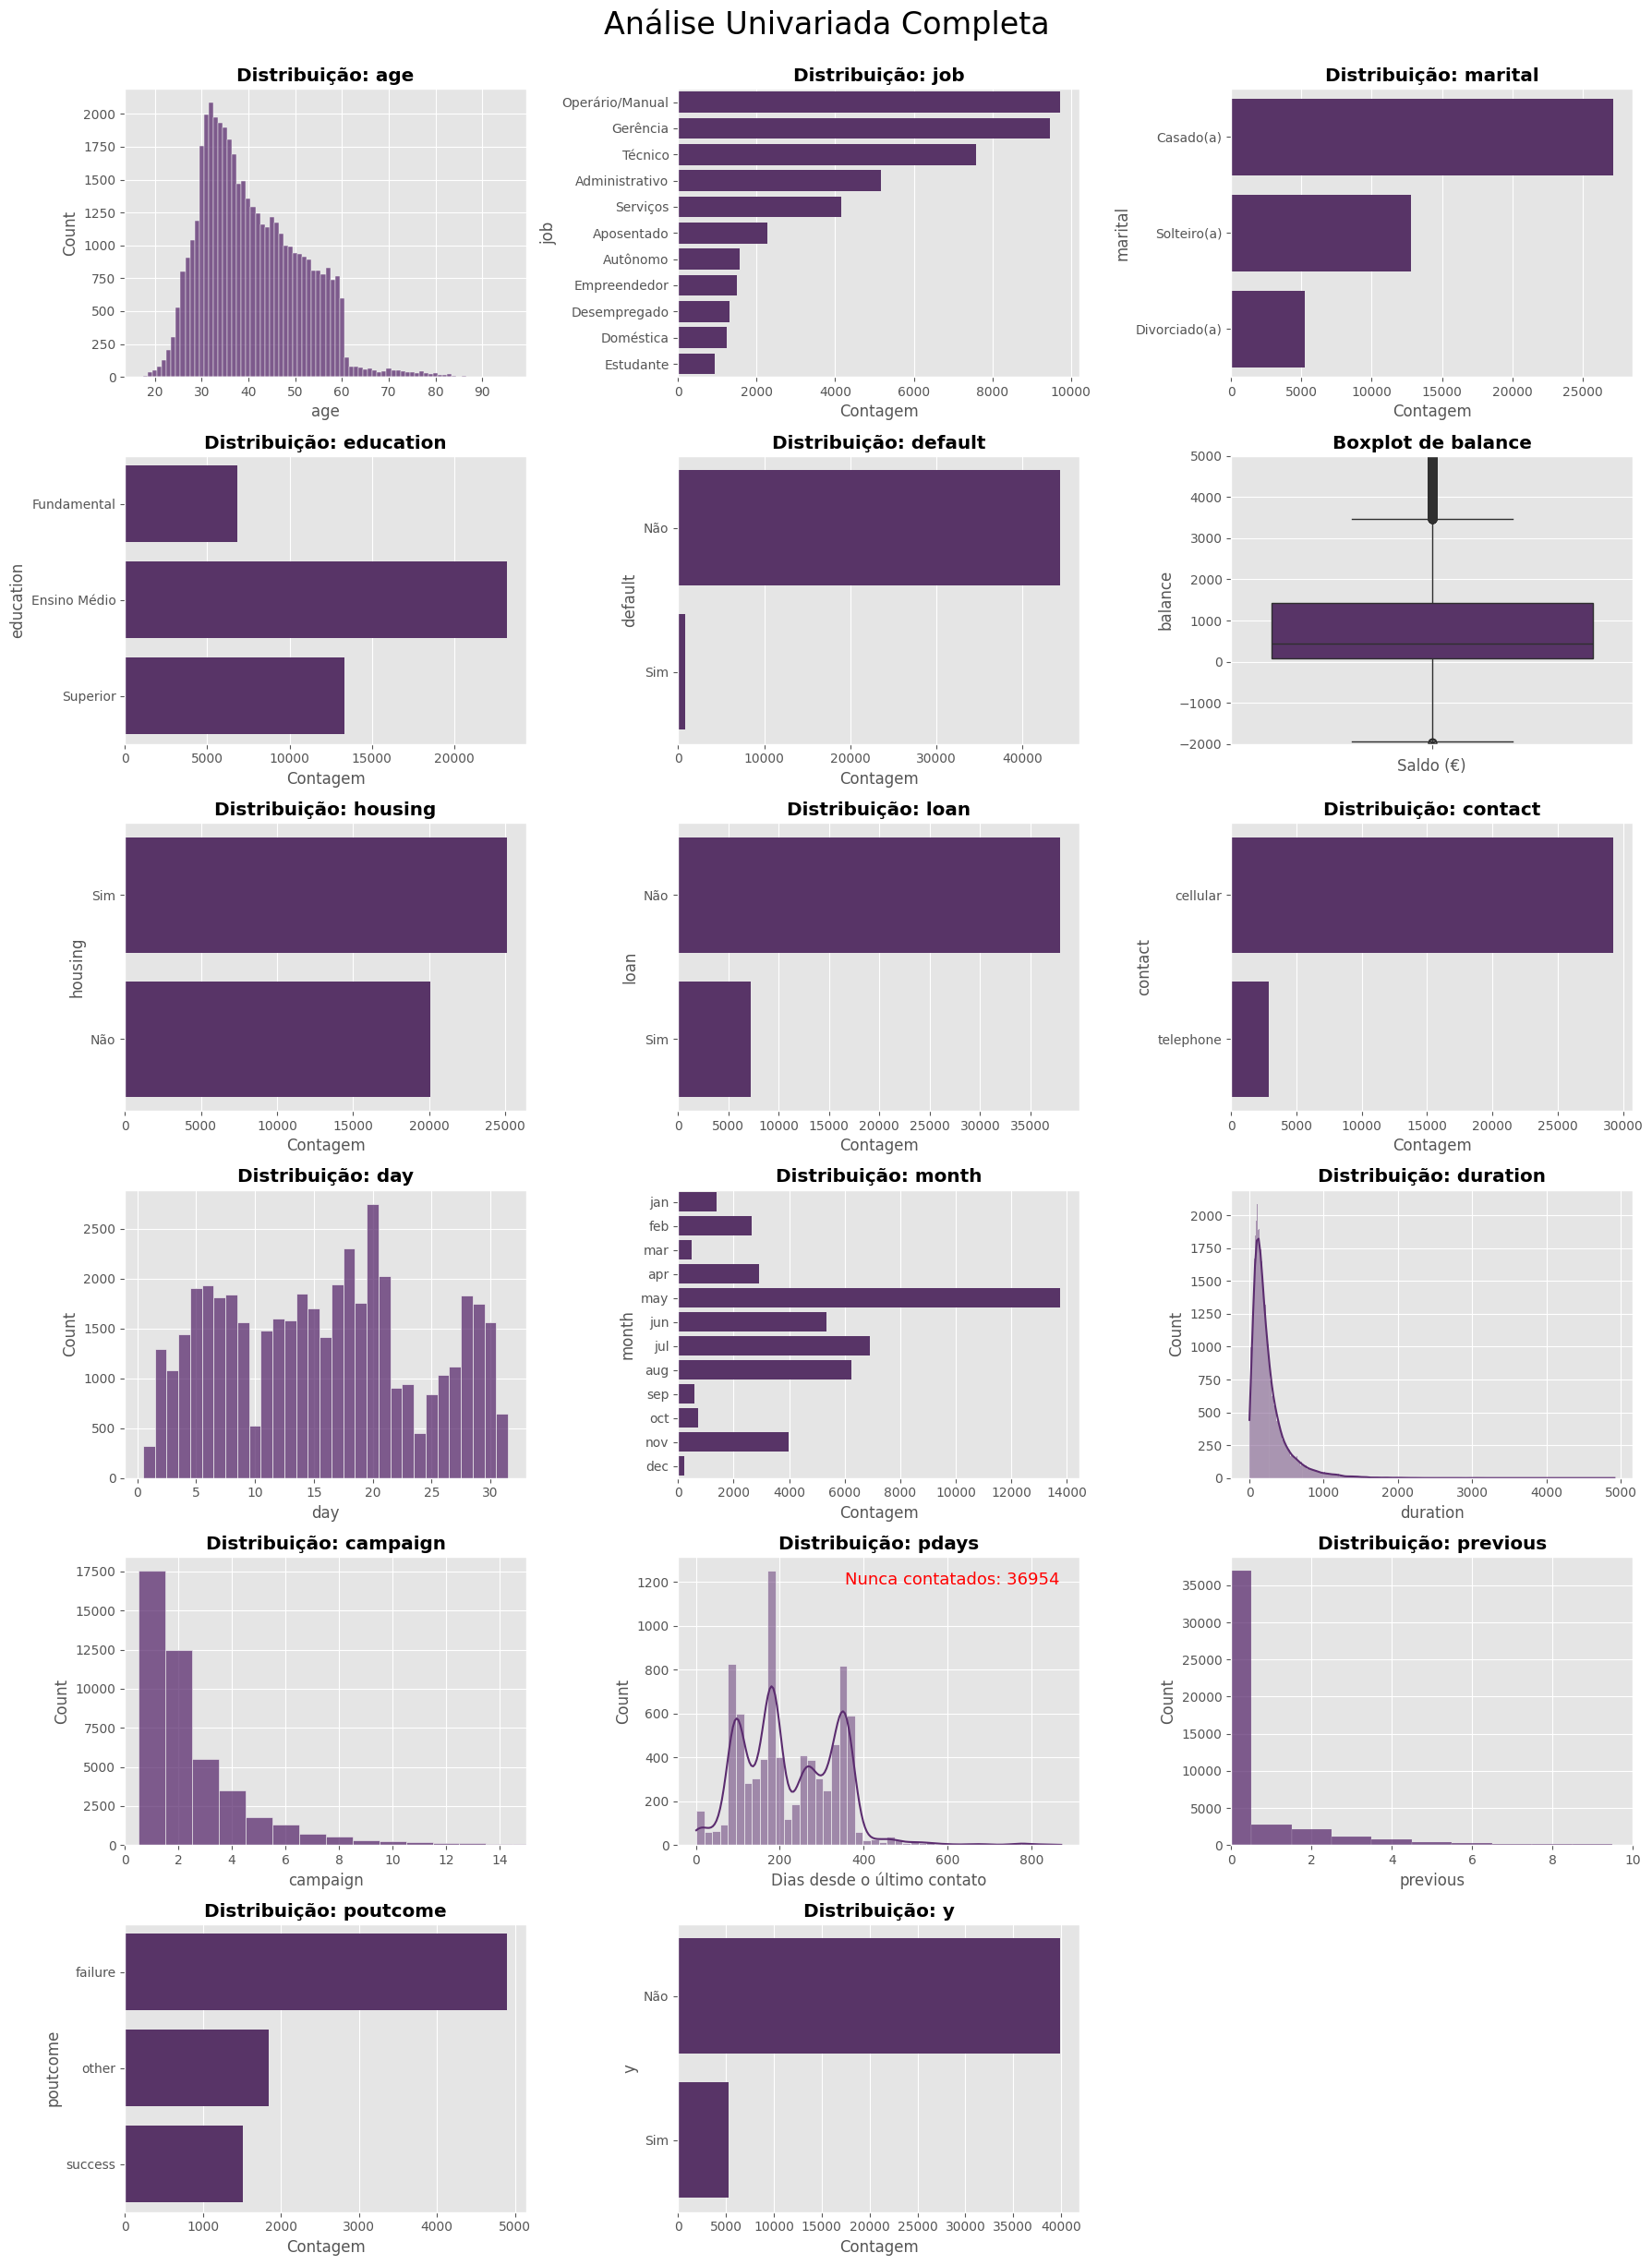

In [9]:
import math

def analise_univariada(df):
    cols = df.columns
    n_cols = 3
    #Arredondando o número de linhas
    n_rows = math.ceil(len(cols)/n_cols) 

    fig,axes = plt.subplots(n_rows, n_cols, figsize = (18,n_rows * 4))
    #Aplananando a matriz axes para fazer o loop for
    axes = axes.flatten()

    for i,col in enumerate(cols):
        ax = axes[i]

        if df[col].dtype == 'object':
            if col == 'education':
                sns.countplot(data=df, y=col,ax=ax,color=cor_base, order = ['Fundamental', 'Ensino Médio', 'Superior'])
            elif col == 'month':
                sns.countplot(data=df, y=col,ax=ax,color=cor_base, order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
            else:
                sns.countplot(data=df, y=col,ax=ax,color=cor_base, order = df[col].value_counts().index)
            ax.set_title(f'Distribuição: {col}', fontweight='bold')
            ax.set_xlabel('Contagem')

        elif col == 'pdays':
            dados_filtrados = df[df[col] != -1]
            sns.histplot(data=dados_filtrados, x=col, ax=ax, color=cor_base, kde=True)
            ax.set_title(f'Distribuição: {col}', fontweight='bold')
            ax.set_xlabel('Dias desde o último contato')
            ax.text(0.95,0.95,f'Nunca contatados: {len(df[df[col] == -1])}', 
                    transform=ax.transAxes, ha='right', va='top', fontsize=13, color='red')
        
        elif col == 'balance':
            sns.boxplot(data=df, y=col, ax=ax, color=cor_base)
            ax.set_title(f'Boxplot de {col}', fontweight='bold')
            ax.set_ylim(-2000,5000)
            ax.set_xlabel('Saldo (€)')            
        
        elif col in ['day', 'campaign', 'previous', 'age']:
            sns.histplot(data=df, x=col, ax=ax, color=cor_base, discrete=True)
            ax.set_title(f'Distribuição: {col}', fontweight='bold')
            if col == 'campaign': ax.set_xlim(0, 15)
            if col == 'previous': ax.set_xlim(0, 10)
        
        else:
            sns.histplot(data=df, x=col, ax=ax, color=cor_base, kde=True)
            ax.set_title(f'Distribuição: {col}', fontweight='bold')
    
    #Deletando os espaços que não possuem gráfico
    for i in range(len(cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.suptitle('Análise Univariada Completa', fontsize=24, y=1.02)
    plt.show()

analise_univariada(bank)

Principais insights:
- Grande parte dos clientes abordados tem entre 30 e 40 anos, são casados, têm apenas o ensino médio completo, não estão endividados, possuem empréstimos apenas imobiliários.
- Os empregos mais comumente vistos são trabalhadores manuais, gerentes e técnicos.
- Mais da metade dos alvos da nossa campanha de marketing têm menos de €1000 de patrimônio.
- A empresa costuma a fazer mais ligações no meio do ano.
- A maioria dos possíveis clientes dessa campanha de marketing nunca havia sido contatado em outras campanhas anteriores.
- As nossas tentativas de cliente tendem a falhar muito mais do que dar certo, nosso objetivo ao final deste projeto é reverter essa situação.

## 3.2 PERFIL DO CLIENTE

### Perfil Demográfico

Começarei analisando o perfil demográfico dos clientes e se existe algum padrão de cliente.

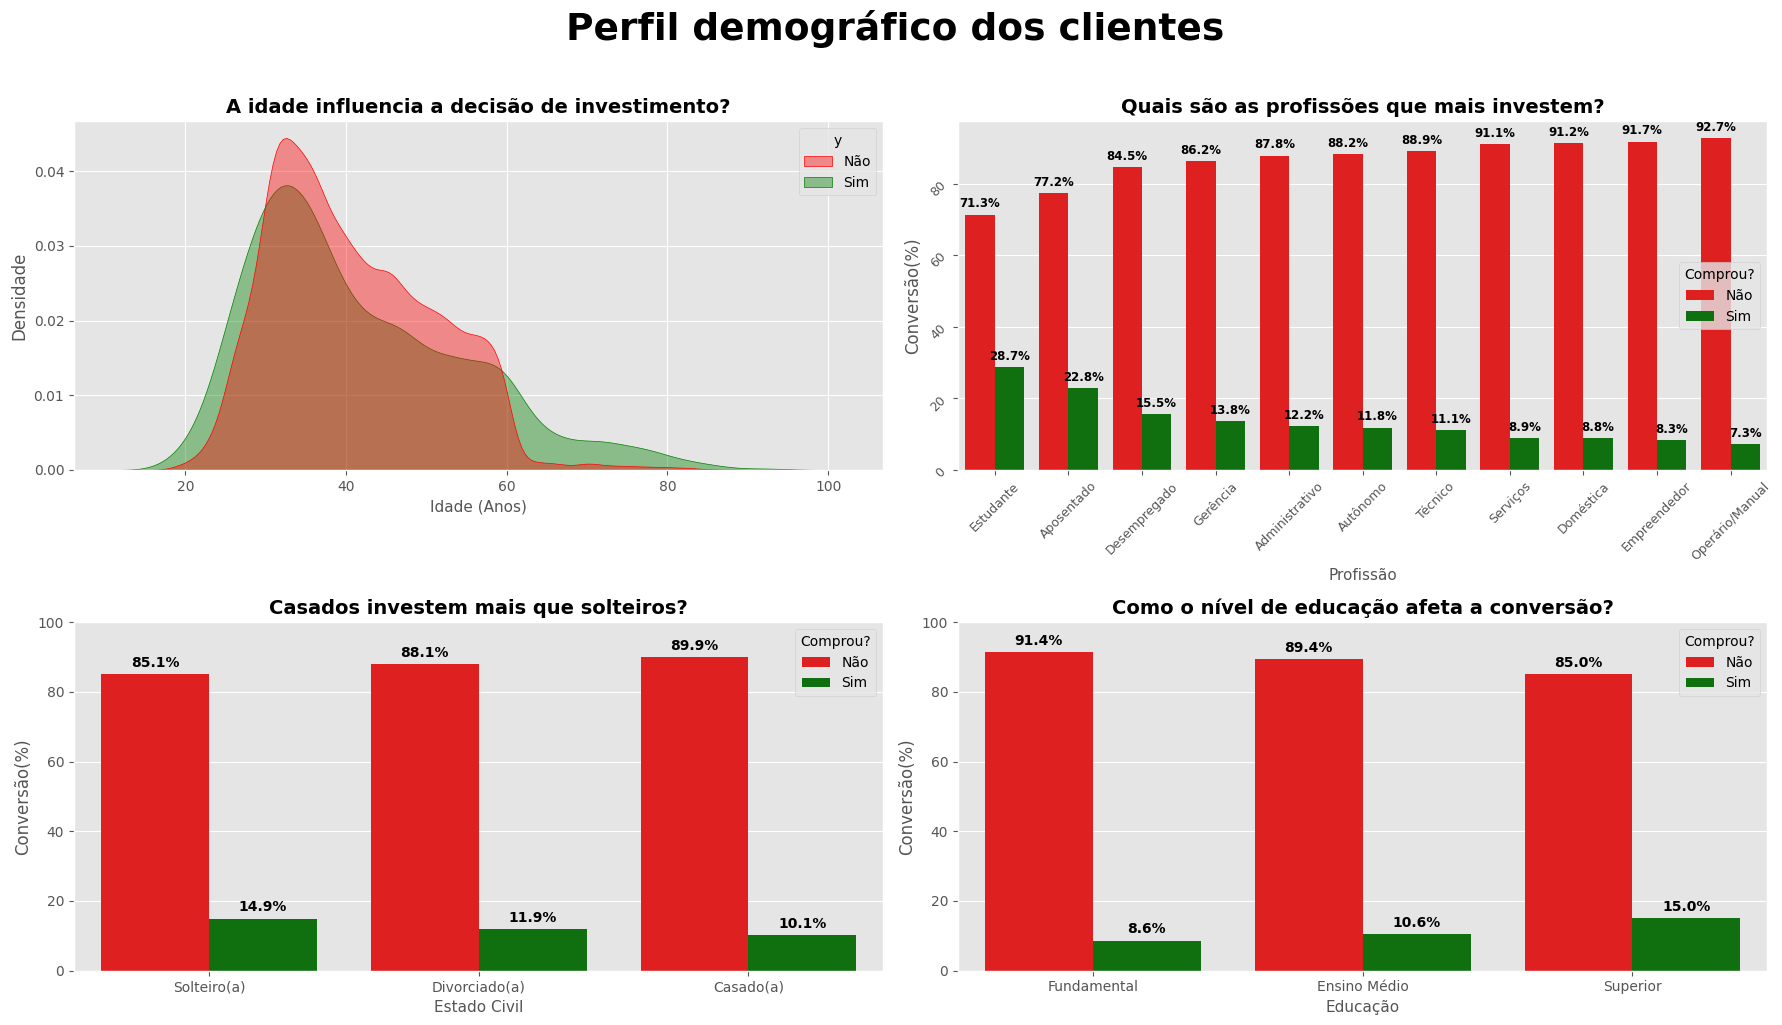

In [10]:
fig, axes = plt.subplots(2,2,figsize=(18,10))

#Distribuição da idade dos Clientes Convertidos ou Não
sns.kdeplot(data=bank, 
            x= 'age', 
            palette={'Não': 'red', 'Sim': 'green'}, 
            ax=axes[0,0], 
            hue='y', 
            fill=True, 
            common_norm=False, 
            alpha=0.4,)
axes[0,0].set_title('A idade influencia a decisão de investimento?', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Idade (Anos)', fontsize=11)
axes[0,0].set_ylabel('Densidade')


#Profissão x Conversão
job_percentage_data = (bank.groupby('job')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())
job_order = job_percentage_data[job_percentage_data['y'] == 'Sim'].sort_values('porcentagem', ascending=False)['job'].values

sns.barplot(data=job_percentage_data,
                x='job',
                y='porcentagem',
                palette={'Não': 'red', 'Sim': 'green'}, 
                ax=axes[0,1], 
                hue='y',
                order=job_order)
axes[0,1].set_title('Quais são as profissões que mais investem?', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Profissão', fontsize=11)
axes[0,1].set_ylabel('Conversão(%)')
axes[0,1].tick_params(rotation=45, labelsize=9)
axes[0,1].legend(title="Comprou?")
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f%%', fontsize=8.5, fontweight='bold', padding=3)

#Estado Civil x Conversão
marital_percentage_data = (bank.groupby('marital')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())
marital_order = marital_percentage_data[marital_percentage_data['y'] == 'Sim'].sort_values('porcentagem', ascending=False)['marital'].values

sns.barplot(data=marital_percentage_data,
            x='marital',
            y='porcentagem', 
            hue='y', 
            palette={'Não': 'red', 'Sim': 'green'},
            ax=axes[1,0],
            order=marital_order)
axes[1,0].set_title('Casados investem mais que solteiros?', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Estado Civil', fontsize=11)
axes[1,0].set_ylabel('Conversão(%)')
axes[1,0].set_ylim(0,100)
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)
axes[1,0].legend(title="Comprou?")

#Educação x Conversão
education_percentage_data = (bank.groupby('education')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=education_percentage_data,
            x='education',
            y='porcentagem', 
            hue='y', 
            palette={'Não': 'red', 'Sim': 'green'},
            order=['Fundamental', 'Ensino Médio', 'Superior'],
            ax=axes[1,1])
axes[1,1].set_title('Como o nível de educação afeta a conversão?', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Educação', fontsize=11)
axes[1,1].set_ylabel('Conversão(%)')
axes[1,1].set_ylim(0,100)
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)
axes[1,1].legend(title="Comprou?")

plt.suptitle('Perfil demográfico dos clientes', fontsize=27, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

Principais Insights:
- Analisando os gráficos, é notório que jovens (até 25 anos) e idosos (acima de 60 anos) tendem a ser convertidos mais facilmente do que adultos, assim como estudantes e aposentados.
- Além disso, solteiros e pessoas com ensino superior também têm mais tendência a investir no nosso produto.

Pensando nisso, eu irei fazer uma análise mais específica usando engenharia de feature, separando as idades por faixa etária.

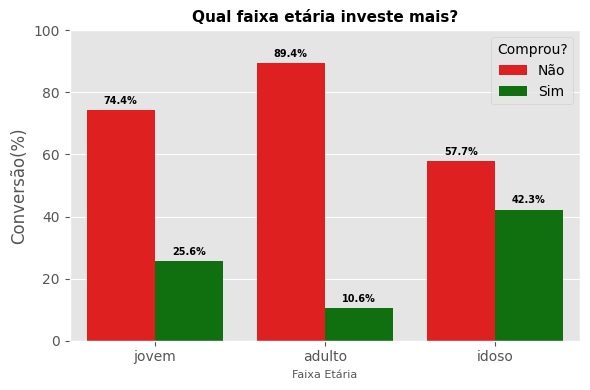

In [11]:
#Criando a coluna faixa etária
def separar_anos(idade):
    if idade < 25:
        return 'jovem'
    elif idade > 60:
        return 'idoso'
    else:
        return 'adulto'
bank['faixa_etaria'] = bank['age'].apply(separar_anos)

fig, ax = plt.subplots(figsize=(6,4))

#Faixa Etária x Conversão
faixa_etaria_percentage_data = (bank.groupby('faixa_etaria')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=faixa_etaria_percentage_data,
            x='faixa_etaria',
            y='porcentagem', 
            hue='y',
            palette={'Não': 'red', 'Sim': 'green'},
            order=['jovem', 'adulto', 'idoso'],
            ax=ax)
ax.set_title('Qual faixa etária investe mais?', fontsize=11, fontweight='bold')
ax.set_xlabel('Faixa Etária', fontsize=8)
ax.set_ylabel('Conversão(%)')
ax.set_ylim(0,100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=7, fontweight='bold', padding=3)
ax.legend(title="Comprou?")

plt.tight_layout()
plt.show()

Analisando o perfil demográfico, é possível ver que o banco estava gastando energia e dinheiro ligando para as pessoas erradas.
- O perfil dos clientes que o banco mais ligava:
    - Entre 30 e 50 anos;
    - Empregos estáveis (operário, gerência, técnico e administrativo);
    - Apenas ensino médio completo;
    - Casados;
- O perfil do cliente com a maior taxa de conversão:
    - Abaixo de 25 anos e acima de 60 anos;
    - Estão estudando, aposentados ou desempregados;
    - Ensino superior completo;
    - Solteiros;

### Perfil Financeiro

Irei analisar agora o perfil financeiro dos clientes que mais tendem a investir no nosso produto.

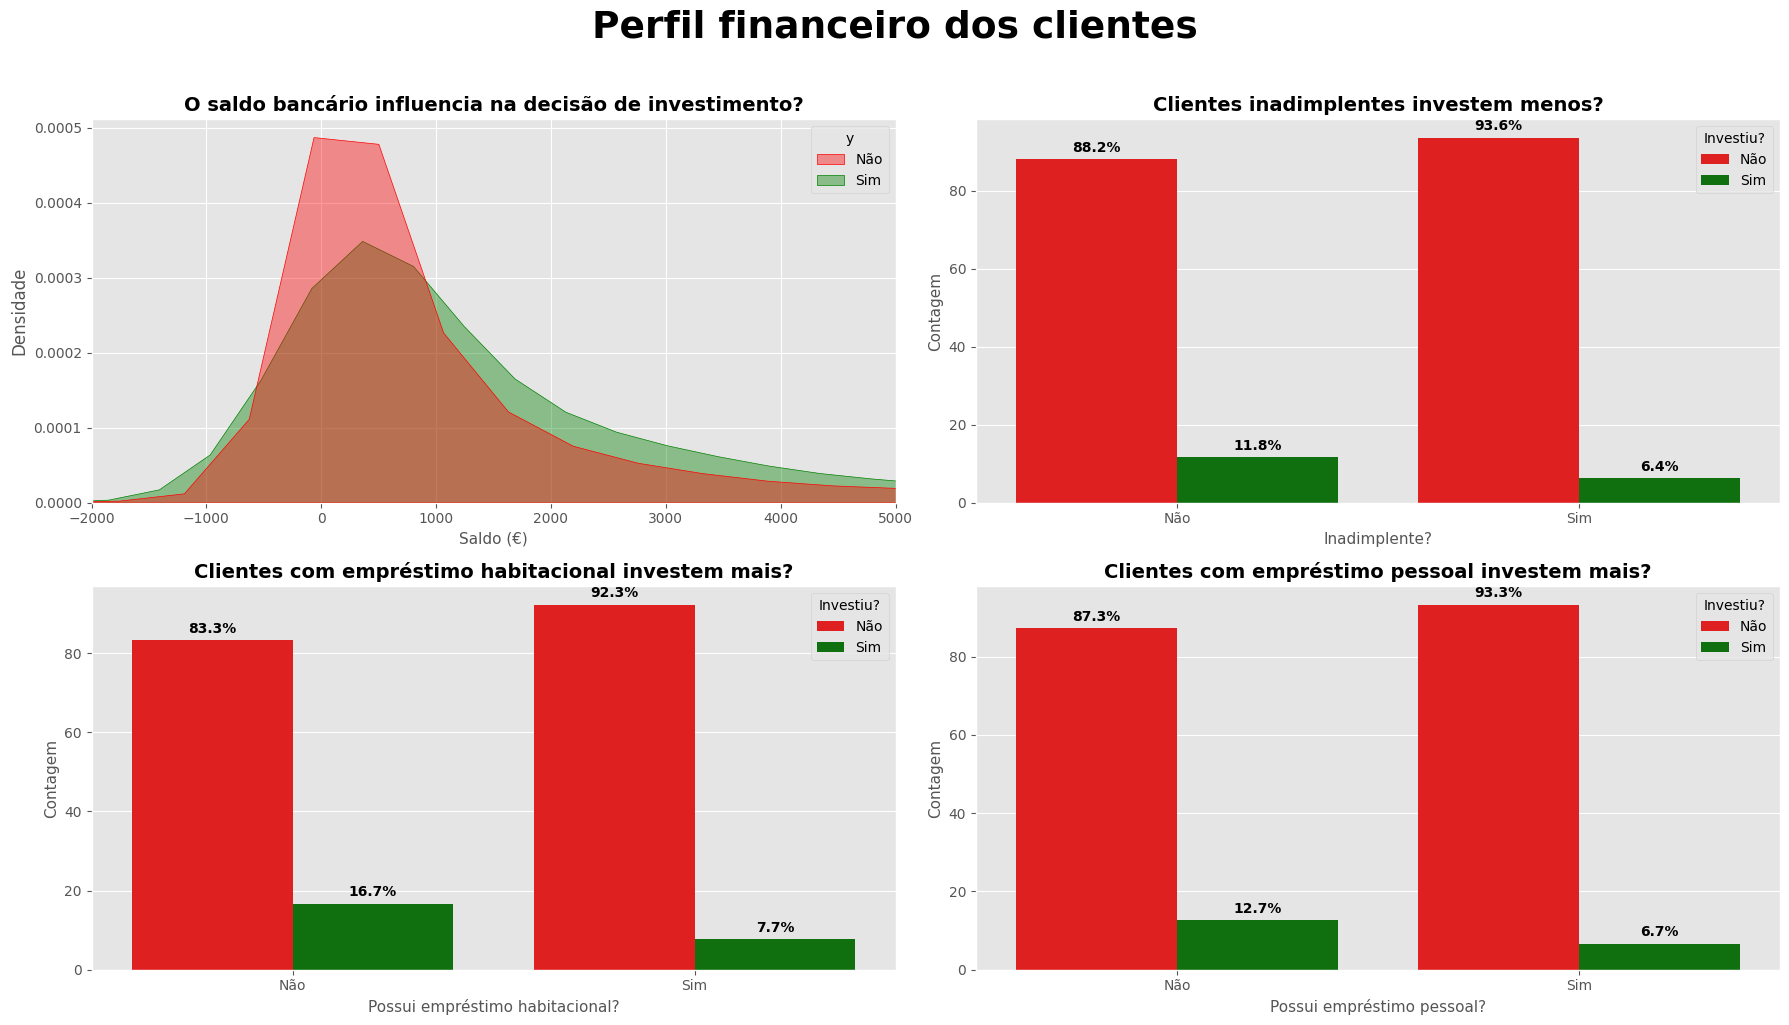

In [12]:
fig, axes = plt.subplots(2,2,figsize=(18,10))

#Saldo vs Conversão
sns.kdeplot(data=bank, 
            x= 'balance', 
            palette={'Não': 'red', 'Sim': 'green'}, 
            ax=axes[0,0], 
            hue='y', 
            fill=True, 
            common_norm=False, 
            alpha=0.4,)
axes[0,0].set_title('O saldo bancário influencia na decisão de investimento?', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Saldo (€)', fontsize=11)
axes[0,0].set_ylabel('Densidade')
axes[0,0].set_xlim(-2000,5000)

#Inadimplência vs Conversão
default_percentage_data = (bank.groupby('default')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=default_percentage_data, 
              x='default', 
              y='porcentagem',
              hue='y', 
              palette={'Não': 'red', 'Sim': 'green'},
              ax=axes[0,1])
axes[0,1].set_title('Clientes inadimplentes investem menos?', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Inadimplente?', fontsize=11)
axes[0,1].set_ylabel('Contagem', fontsize=11)
axes[0,1].legend(title="Investiu?")
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

#Empréstimo Habitação vs Conversão
housing_percentage_data = (bank.groupby('housing')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=housing_percentage_data, 
              x='housing',
              y='porcentagem',
              hue='y', 
              palette={'Não': 'red', 'Sim': 'green'},
              ax=axes[1,0])
axes[1,0].set_title('Clientes com empréstimo habitacional investem mais?', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Possui empréstimo habitacional?', fontsize=11)
axes[1,0].set_ylabel('Contagem', fontsize=11)
axes[1,0].legend(title="Investiu?")
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

#Empréstimo Pessoal vs Conversão
loan_percentage_data = (bank.groupby('loan')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=loan_percentage_data, 
              x='loan',
              y='porcentagem',
              hue='y', 
              palette={'Não': 'red', 'Sim': 'green'},
              ax=axes[1,1])
axes[1,1].set_title('Clientes com empréstimo pessoal investem mais?', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Possui empréstimo pessoal?', fontsize=11)
axes[1,1].set_ylabel('Contagem', fontsize=11)
axes[1,1].legend(title="Investiu?")
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

plt.suptitle('Perfil financeiro dos clientes', fontsize=27, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Principais insights:
- Os clientes com mais de 1000 euros de saldo investem mais frequentemente.
- Os clientes sem nenhum tipo de dívida, tanto pessoal quanto habitacional, e que não possuem nenhuma inadimplência tendem a ser convertidos com mais facilidade.

## 3.3 Comportamento dos clientes

Nessa etapa irei buscar entender o comportamento do cliente, para isso vou dividir a análise em duas partes:
- Fidelidade (clientes que já foram contatados em campanhas anteriores costumam investir mais vezes?)
- Sazonalidade (existe algum período do ano no qual os clientes investem mais nos produtos?)

### Fidelidade

Para verificar se os clientes que já foram contatados anteriormente são convertidos mais facilmentes, irei criar uma nova coluna chamada "tipo_cliente". Separando os clientes em novos (pdays = -1) e antigos (pdays ≠ -1).

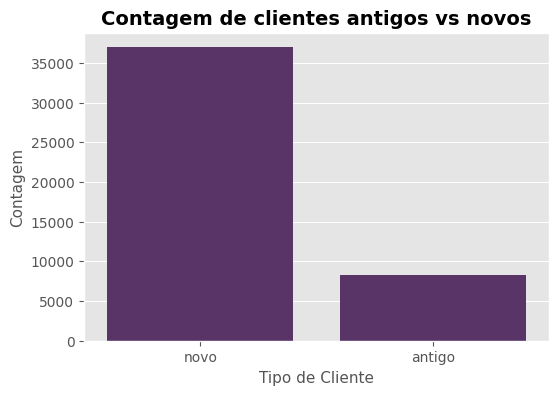

In [14]:
bank['tipo_cliente'] = bank['pdays'].apply(lambda x: 'antigo' if x != -1 else 'novo')

fig, ax = plt.subplots(figsize=(6,4))
#Tipo de Cliente x Conversão
sns.countplot(data=bank, 
                x='tipo_cliente',
                color=cor_base,
                ax=ax)
ax.set_title('Contagem de clientes antigos vs novos', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Cliente', fontsize=11)
ax.set_ylabel('Contagem', fontsize=11)

plt.show()

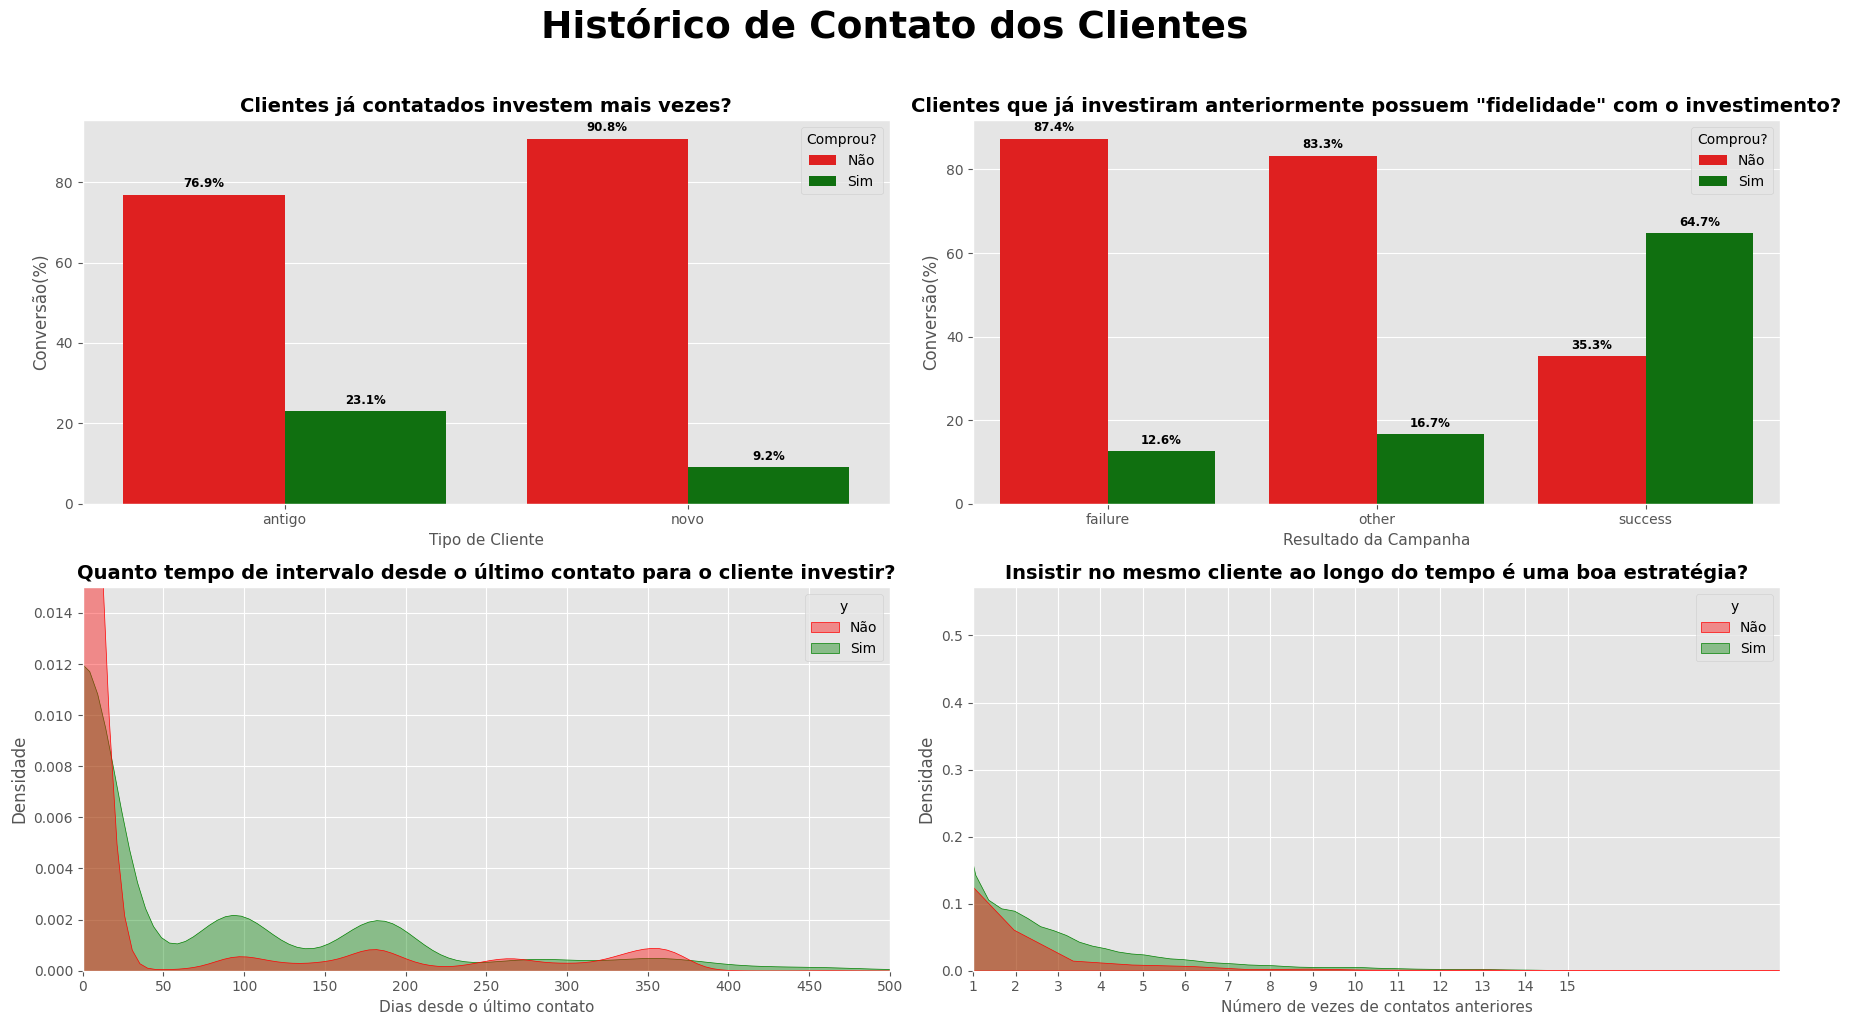

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(18,10))

#cliente antigo vs novo
tipo_cliente_percentage_data = (bank.groupby('tipo_cliente')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=tipo_cliente_percentage_data,
                x='tipo_cliente',
                y='porcentagem',
                palette={'Não': 'red', 'Sim': 'green'}, 
                ax=axes[0,0], 
                hue='y')
axes[0,0].set_title('Clientes já contatados investem mais vezes?', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Tipo de Cliente', fontsize=11)
axes[0,0].set_ylabel('Conversão(%)')
axes[0,0].legend(title="Comprou?")
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%.1f%%', fontsize=8.5, fontweight='bold', padding=3)

#Clientes que já investiram anteriormente tendem a investir novamente?
poutcome_percentage_data = (bank.groupby('poutcome')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.barplot(data=poutcome_percentage_data,
                x='poutcome',
                y='porcentagem',
                palette={'Não': 'red', 'Sim': 'green'},
                ax=axes[0,1],
                hue='y')
axes[0,1].set_title('Clientes que já investiram anteriormente possuem "fidelidade" com o investimento?', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Resultado da Campanha', fontsize=11)
axes[0,1].set_ylabel('Conversão(%)')
axes[0,1].legend(title="Comprou?")
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f%%', fontsize=8.5, fontweight='bold', padding=3)

#pdays vs conversão
sns.kdeplot(data=bank, 
            x= 'pdays', 
            palette={'Não': 'red', 'Sim': 'green'}, 
            ax=axes[1,0], 
            hue='y', 
            fill=True, 
            common_norm=False, 
            alpha=0.4,)
axes[1,0].set_title('Quanto tempo de intervalo desde o último contato para o cliente investir?', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Dias desde o último contato', fontsize=11)
axes[1,0].set_ylabel('Densidade')
axes[1,0].set_xlim(0,500)
axes[1,0].set_ylim(0,0.015)
axes[1,0].set_xticks(np.arange(0, 501, 50))

#previous vs conversão
sns.kdeplot(data=bank, 
            x= 'previous', 
            palette={'Não': 'red', 'Sim': 'green'}, 
            ax=axes[1,1], 
            hue='y', 
            fill=True, 
            common_norm=False, 
            alpha=0.4,)
axes[1,1].set_title('Insistir no mesmo cliente ao longo do tempo é uma boa estratégia?', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Número de vezes de contatos anteriores', fontsize=11)
axes[1,1].set_ylabel('Densidade')
axes[1,1].set_xlim(1,20)
axes[1,1].set_xticks(np.arange(1, 16, 1))

plt.suptitle('Histórico de Contato dos Clientes', fontsize=27, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Principais insights:
- Os clientes já contatados anteriormente investem mais do que os novos.
- Existe uma grande fidelidade dos clientes em que já investiram anteriormente.
- É recomendado contatar o cliente num período de 20 até 250 dias após o último contato.

### Sazonalidade

Agora, vamos verificar a sazonalidade verificando os meses do ano com maior conversão e comparar com os meses que o banco mais costuma realizar chamadas.

C:\Users\felip\AppData\Local\Temp\ipykernel_1368\1497195491.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_percentage_data = (bank.groupby('month')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())


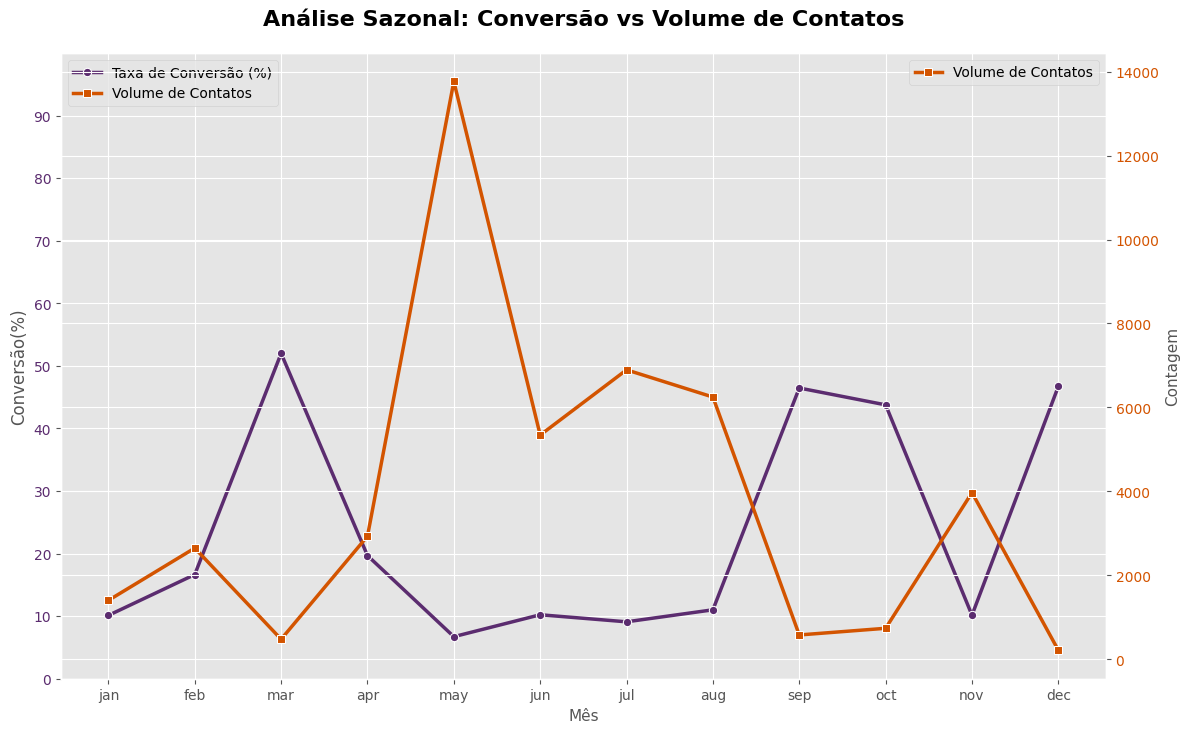

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Dados da Taxa de Conversão por Mês
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
bank['month'] = pd.Categorical(bank['month'], categories=month_order, ordered=True)
month_percentage_data = (bank.groupby('month')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

# Dados do Número de Contatos por Mês
month_counts = bank['month'].value_counts().sort_index()

#Mêses vs Taxa de Conversão
line1 =sns.lineplot(data=month_percentage_data[month_percentage_data['y']=='Sim'], 
                x='month',
                y='porcentagem',
                color=cor_base,
                marker='o',
                linewidth=2.5,
                ax=ax,
                label='Taxa de Conversão (%)')
ax.set_xlabel('Mês', fontsize=11)
ax.tick_params(axis='y', labelcolor=cor_base)
ax.set_ylabel('Conversão(%)')
ax.set_ylim(0,100)
ax.set_yticks(np.arange(0,100, 10))

#Mêses vs Número de Contatos
ax2 = ax.twinx()

line2= sns.lineplot(data=bank['month'].value_counts().sort_index().reset_index(), 
              x='month',
              y=bank['month'].value_counts().sort_index().values,
              ax=ax2,
              color=cor_secundaria,
              linewidth=2.5,
              marker='s',
              label='Volume de Contatos')
ax2.set_ylabel('Contagem', fontsize=11)
ax2.tick_params(axis='y', labelcolor=cor_secundaria)
ax2.set_xlabel('Mês', fontsize=11)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('Análise Sazonal: Conversão vs Volume de Contatos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Principais insights:
- Os melhores meses de conversão são: março, setembro e dezembro.
- Porém algo muito preocupante que podemos observar é que existe um trade-off entre quantidade e qualidade:
    - Campanhas de alto volume capturam leads menos qualificados.
    - Abordagens mais seletivas (baixo volume) conseguem leads melhores.

## 3.4 OPERAÇÃO

Agora, irei verificar qual tipo de abordagem com os clientes resulta em mais conversão.

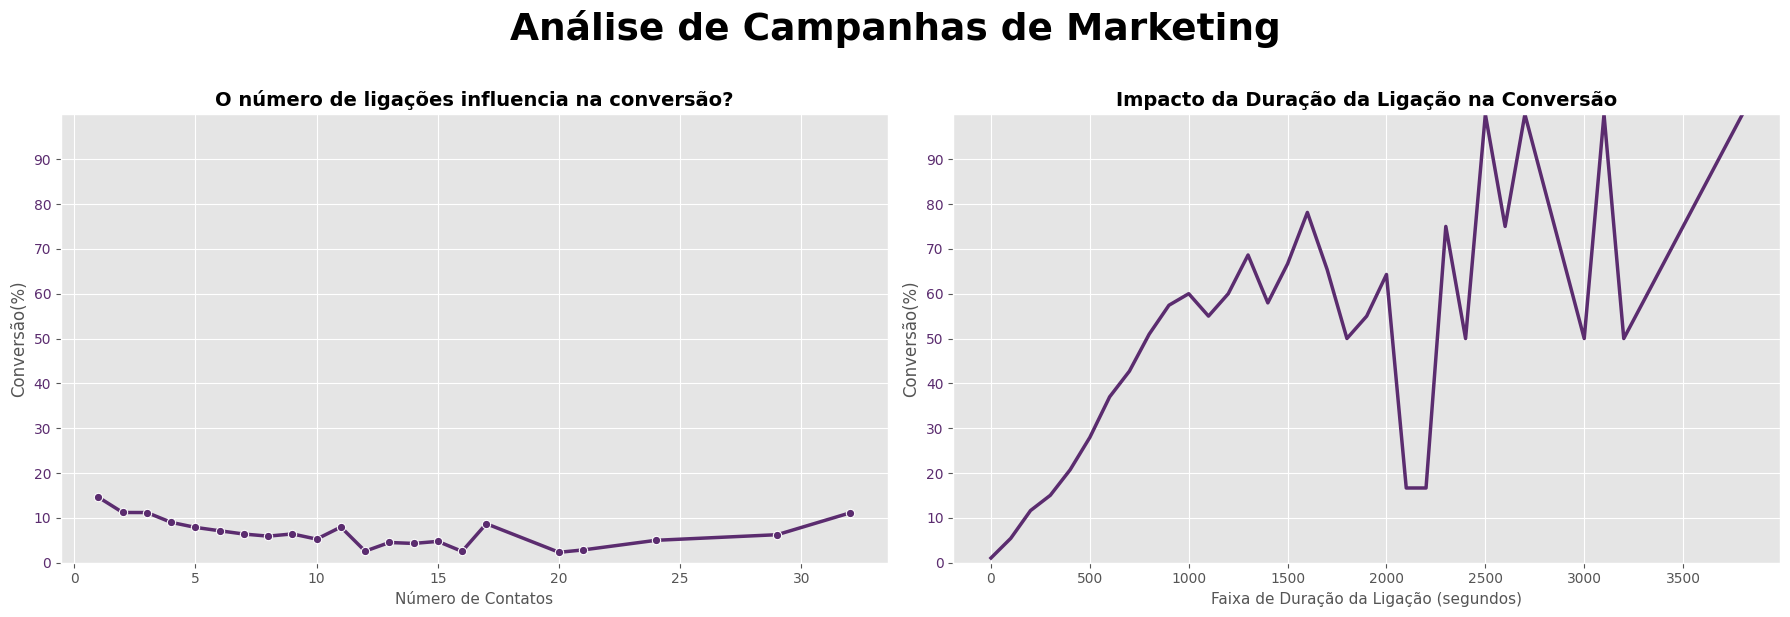

In [189]:
fig, axes = plt.subplots(1,2,figsize=(18,6))

#campaign vs conversão
campaign_percentage_data = (bank.groupby('campaign')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.lineplot(data=campaign_percentage_data[campaign_percentage_data['y']=='Sim'], 
                x='campaign',
                y='porcentagem',
                color=cor_base,
                marker='o',
                linewidth=2.5,
                ax=axes[0])
axes[0].set_xlabel('Número de Contatos', fontsize=11)
axes[0].tick_params(axis='y', labelcolor=cor_base)
axes[0].set_ylabel('Conversão(%)')
axes[0].set_ylim(0,100)
axes[0].set_yticks(np.arange(0,100, 10))
axes[0].set_title('O número de ligações influencia na conversão?', fontsize=14, fontweight='bold')

#duration vs conversão
bank['duration_bin'] = (bank['duration'] // 100) * 100
duration_percentage_data = (bank.groupby('duration_bin')['y'].value_counts(normalize=True).mul(100).rename('porcentagem').reset_index())

sns.lineplot(data=duration_percentage_data[duration_percentage_data['y']=='Sim'], 
                x='duration_bin',
                y='porcentagem',
                color=cor_base,
                linewidth=2.5,
                ax=axes[1])
axes[1].set_xlabel('Faixa de Duração da Ligação (segundos)', fontsize=11)
axes[1].tick_params(axis='y', labelcolor=cor_base)
axes[1].set_ylabel('Conversão(%)')
axes[1].set_ylim(0,100)
axes[1].set_yticks(np.arange(0,100, 10))
axes[1].set_title('Impacto da Duração da Ligação na Conversão', fontsize=14, fontweight='bold')

plt.suptitle('Análise de Campanhas de Marketing', fontsize=27, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Principais Insights:
- O número de ligações tem pouco impacto na porcentagem de conversão.
- Quanto mais longa a conversa, mais o cliente fica interessado no produto, logo a equipe de marketing responsável pela ligação deve ter a habilidade de envolver o cliente por mais tempo possível na ligação.

# 4. CONCLUSÃO

Ao final da nossa análise, chegamos nas seguinte conclusões:

- Perfil do Cliente:
  - O perfil dos clientes que o banco mais ligava:
    - Entre 30 e 50 anos;
    - Empregos estáveis (operário, gerência, técnico e administrativo);
    - Apenas ensino médio completo;
    - Casados;
    - Menos de 1000 euros de saldo;
    - Empréstimo imobiliário sendo pago;
    - Nunca haviam sido contatados anteriormente;
  
  - O perfil do cliente com a maior taxa de conversão:
    - Abaixo de 25 anos e acima de 60 anos;
    - Estão estudando, aposentados ou desempregados;
    - Ensino superior completo;
    - Solteiros;
    - Saldo acima de 1000 euros;
    - Sem nenhum tipo de inadimplência ou empréstimo;
    - Já foram contatados anteriormente;

- Fatores Operacionais de Sucesso:
  - Qualidade > Quantidade: Os meses em que menos ligamos para o cliente, foram os meses com maior taxa de conversão.
  - Engajamento na Chamada: Existe uma correlação direta entre o tempo de chamada e a venda. Ligações curtas (< 2 min) raramente convertem. O objetivo do operador deve ser manter o cliente engajado, pois o tempo de conversa é o maior sinal de interesse.

- Recomendações:
  - Reorientação da segmentação de marketing: Priorizar clientes que já foram contatados anteriormente e principalmente os que a antiga abordagem foi um sucesso, e para clientes novos, mudar o alvo das campanhas para o perfil com maior taxa de conversão.
  - Foco em qualidade de lead: Para aumentar a eficiência das campanhas de marketing, a prioridade deve ser a qualidade ao invés da quantidade, pois como vimos na nossa análise, existe um trade-off entre ambas.
  - Treinamento e Qualidade da Equipe de Vendas: A correlação positiva entre a duração da ligação e a conversão indica que a qualidade da interação é crucial. É imperativo investir em treinamento para a equipe de telemarketing, focando em habilidades de engajamento, retenção do cliente na linha e aprofundamento da conversa sobre o produto.
  - Programa de Fidelidade: Criar um programa estruturado para reengajar clientes que já converteram anteriormente. Estes clientes demonstram uma propensão muito maior a investir novamente.
